## 1. 目的

Machine failureを予測する二値分類モデルのベースラインを構築する。

まずDummyClassifierによって最低限の基準となる性能を確認し、
その後LogisticRegressionを構築して比較する。

Machine failureは全体の約3.39%とクラス不均衡が大きいため、
AccuracyだけではなくPrecision、Recall、F1、ROC-AUC、PR-AUCを用いて評価する。

特に予知保全では故障設備の見逃し（False Negative）が重要になるため、
Recallを重視しながらPrecisionとのバランスを評価する。

## 2. データ読み込み

In [29]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(10000, 14)

In [30]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. 特徴量と目的変数の定義

In [31]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

categorical_features = [
    "Type",
]

target = "Machine failure"

X = df[numeric_features + categorical_features]
y = df[target]

In [32]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
0,298.1,308.6,1551,42.8,0,M
1,298.2,308.7,1408,46.3,3,L
2,298.1,308.5,1498,49.4,5,L
3,298.2,308.6,1433,39.5,7,L
4,298.2,308.7,1408,40.0,9,L


In [33]:
X.shape, y.shape

((10000, 6), (10000,))

In [34]:
y.value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

## 4. Train / Test分割

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [36]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 6)
Test: (2000, 6)


In [37]:
print("Train")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print()

print("Test")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Train
Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Test
Machine failure
0    1932
1      68
Name: count, dtype: int64
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


## 5. 前処理

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Type'])])

## 6. DummyClassifier

In [39]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="prior",
                random_state=42,
            ),
        ),
    ]
)

dummy_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier', DummyClassifier(random_state=42))])

In [40]:
dummy_pred = dummy_model.predict(X_test)
dummy_proba = dummy_model.predict_proba(X_test)[:, 1]

In [41]:
pd.Series(dummy_pred).value_counts()

0    2000
Name: count, dtype: int64

In [42]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def evaluate_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(y_true, y_proba),
    }

In [43]:
dummy_metrics = evaluate_model(
    y_test,
    dummy_pred,
    dummy_proba,
)

pd.Series(dummy_metrics)

Accuracy             0.966
Precision            0.000
Recall               0.000
F1                   0.000
ROC-AUC              0.500
Average Precision    0.034
dtype: float64

In [44]:
dummy_cm = confusion_matrix(
    y_test,
    dummy_pred,
)

dummy_cm

array([[1932,    0],
       [  68,    0]])

### DummyClassifierの目的

DummyClassifierは、今後構築する機械学習モデルが最低限超えるべき
ベースライン性能を確認するために使用する。

本データではMachine failureが約3.4%しか存在しないため、
多数派である正常クラスを予測するだけでも高いAccuracyを得られる可能性がある。

そのためAccuracyだけではなく、故障クラスに対するPrecision、Recall、F1、
ROC-AUC、PR-AUCおよびConfusion Matrixを確認する。

特に本プロジェクトでは、実際には故障する設備を正常と判定する
False Negative（故障の見逃し）を重要視する。

### DummyClassifierの評価

DummyClassifierはTestデータ2,000件すべてを正常（Machine failure = 0）
と予測した。

その結果、Accuracyは0.966と高い値になった一方で、
実際に故障した68件を1件も検出できず、Recallは0となった。

また、ROC-AUCは0.500、PR-AUCは0.034であり、
故障設備を識別する能力を持たないことが確認された。

この結果から、クラス不均衡の大きい本データでは
Accuracyだけでモデルを評価すると性能を誤って解釈する可能性がある。

以降のモデルでは、故障設備の検出性能を評価するため、
特にRecall、Precision、F1、PR-AUCを重視する。

## 7. LogisticRegression

In [45]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [46]:
logistic_pred = logistic_model.predict(X_test)
logistic_proba = logistic_model.predict_proba(X_test)[:, 1]

In [47]:
logistic_metrics = evaluate_model(
    y_test,
    logistic_pred,
    logistic_proba,
)

pd.Series(logistic_metrics)

Accuracy             0.967500
Precision            0.636364
Recall               0.102941
F1                   0.177215
ROC-AUC              0.899388
Average Precision    0.420537
dtype: float64

In [48]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_pred,
)

logistic_cm

array([[1928,    4],
       [  61,    7]])

In [49]:
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

balanced_logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [50]:
balanced_logistic_pred = balanced_logistic_model.predict(X_test)

balanced_logistic_proba = (
    balanced_logistic_model.predict_proba(X_test)[:, 1]
)

In [51]:
balanced_logistic_metrics = evaluate_model(
    y_test,
    balanced_logistic_pred,
    balanced_logistic_proba,
)

pd.Series(balanced_logistic_metrics)

Accuracy             0.824500
Precision            0.141772
Recall               0.823529
F1                   0.241901
ROC-AUC              0.906954
Average Precision    0.381762
dtype: float64

In [52]:
balanced_logistic_cm = confusion_matrix(
    y_test,
    balanced_logistic_pred,
)

balanced_logistic_cm

array([[1593,  339],
       [  12,   56]])

In [53]:
baseline_results = pd.DataFrame(
    {
        "Dummy": dummy_metrics,
        "LogisticRegression": logistic_metrics,
        "LogisticRegression Balanced": balanced_logistic_metrics,
    }
).T

baseline_results

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Dummy,0.9660,0.000000,0.000000,0.000000,0.500000,0.034000
LogisticRegression,0.9675,0.636364,0.102941,0.177215,0.899388,0.420537
LogisticRegression Balanced,0.8245,0.141772,0.823529,0.241901,0.906954,0.381762


### LogisticRegressionの比較

通常のLogisticRegressionでは、Precisionは0.636だった一方、
Recallは0.103にとどまった。

故障と予測した設備については比較的高い精度で故障を検出できているが、
実際の故障68件のうち検出できたのは7件で、61件を見逃した。

一方、class_weight="balanced"を設定したLogisticRegressionでは、
Recallが0.824まで大きく向上し、故障68件のうち56件を検出できた。

その一方でPrecisionは0.142まで低下し、
正常設備1,932件のうち339件を故障と誤判定した。

この結果から、クラス重みを調整することで故障の見逃しを大幅に減らせる一方、
False Positiveが増加するトレードオフが確認された。

予知保全では故障の見逃しを減らすことが重要であるが、
False Positiveが多すぎると不要な点検作業が増加する。

そのため、モデルの採用にはRecallだけではなく、
Precisionとのバランスや業務上許容できる誤検知数を考慮する必要がある。

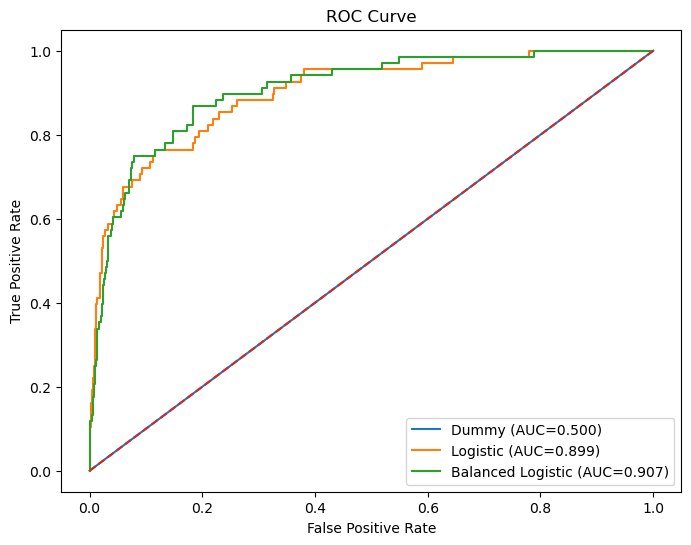

In [54]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

dummy_fpr, dummy_tpr, _ = roc_curve(
    y_test,
    dummy_proba,
)

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_proba,
)

balanced_fpr, balanced_tpr, _ = roc_curve(
    y_test,
    balanced_logistic_proba,
)

plt.figure(figsize=(8, 6))

plt.plot(
    dummy_fpr,
    dummy_tpr,
    label=f"Dummy (AUC={dummy_metrics['ROC-AUC']:.3f})",
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic (AUC={logistic_metrics['ROC-AUC']:.3f})",
)

plt.plot(
    balanced_fpr,
    balanced_tpr,
    label=f"Balanced Logistic (AUC={balanced_logistic_metrics['ROC-AUC']:.3f})",
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

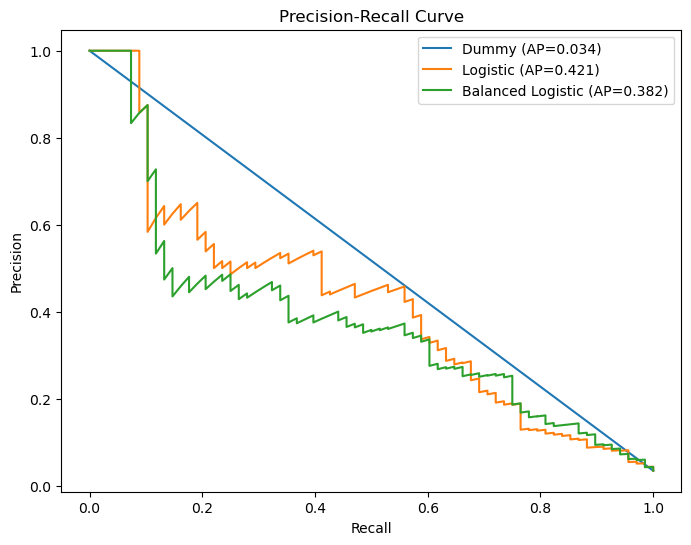

In [56]:
from sklearn.metrics import precision_recall_curve

dummy_precision, dummy_recall, _ = precision_recall_curve(
    y_test,
    dummy_proba,
)

logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_test,
    logistic_proba,
)

balanced_precision, balanced_recall, _ = precision_recall_curve(
    y_test,
    balanced_logistic_proba,
)

plt.figure(figsize=(8, 6))

plt.plot(
    dummy_recall,
    dummy_precision,
    label=f"Dummy (AP={dummy_metrics['Average Precision']:.3f})",
)

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic (AP={logistic_metrics['Average Precision']:.3f})",
)

plt.plot(
    balanced_recall,
    balanced_precision,
    label=f"Balanced Logistic (AP={balanced_logistic_metrics['Average Precision']:.3f})",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [57]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

In [58]:
print("Sub-train:", X_subtrain.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

print()
print("Sub-train failure rate:", y_subtrain.mean())
print("Validation failure rate:", y_valid.mean())
print("Test failure rate:", y_test.mean())

Sub-train: (6400, 6)
Validation: (1600, 6)
Test: (2000, 6)

Sub-train failure rate: 0.03390625
Validation failure rate: 0.03375
Test failure rate: 0.034


In [59]:
threshold_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

threshold_model.fit(
    X_subtrain,
    y_subtrain,
)

valid_proba = threshold_model.predict_proba(X_valid)[:, 1]

In [60]:
import numpy as np

thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:
    valid_pred = (valid_proba >= threshold).astype(int)

    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_valid,
                valid_pred,
                zero_division=0,
            ),
            "recall": recall_score(
                y_valid,
                valid_pred,
                zero_division=0,
            ),
            "f1": f1_score(
                y_valid,
                valid_pred,
                zero_division=0,
            ),
        }
    )

threshold_results = pd.DataFrame(threshold_results)

threshold_results.head()

,threshold,precision,recall,f1
0,0.05,0.177966,0.777778,0.289655
1,0.06,0.205263,0.722222,0.319672
2,0.07,0.220930,0.703704,0.336283
3,0.08,0.243590,0.703704,0.361905
4,0.09,0.266187,0.685185,0.383420


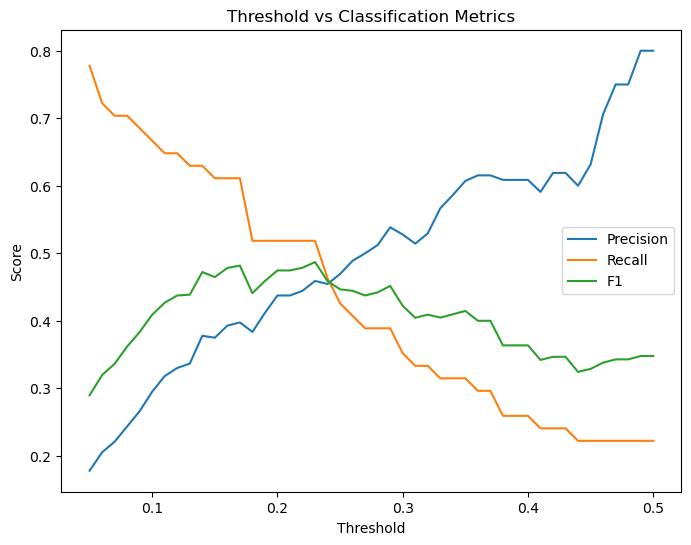

In [61]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision",
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall",
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Classification Metrics")
plt.legend()
plt.show()

In [62]:
threshold_candidates = threshold_results[
    threshold_results["recall"] >= 0.80
]

threshold_candidates.sort_values(
    "precision",
    ascending=False,
).head(10)

,threshold,precision,recall,f1


In [63]:
thresholds = np.linspace(
    0.01,
    0.50,
    100,
)

threshold_results = []

for threshold in thresholds:
    valid_pred = (valid_proba >= threshold).astype(int)

    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_valid,
                valid_pred,
                zero_division=0,
            ),
            "recall": recall_score(
                y_valid,
                valid_pred,
                zero_division=0,
            ),
            "f1": f1_score(
                y_valid,
                valid_pred,
                zero_division=0,
            ),
        }
    )

threshold_results = pd.DataFrame(threshold_results)

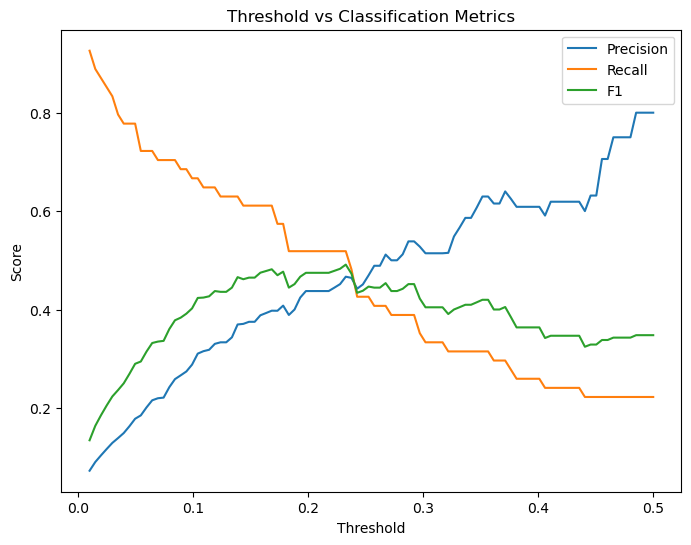

In [64]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision",
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall",
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Classification Metrics")
plt.legend()
plt.show()

In [65]:
threshold_candidates = threshold_results[
    threshold_results["recall"] >= 0.80
].copy()

threshold_candidates.sort_values(
    ["precision", "threshold"],
    ascending=[False, False],
).head(10)

,threshold,precision,recall,f1
4,0.029798,0.128940,0.833333,0.223325
3,0.024848,0.116456,0.851852,0.204900
2,0.019899,0.103524,0.870370,0.185039
1,0.014949,0.090056,0.888889,0.163543
0,0.010000,0.072359,0.925926,0.134228


In [66]:
best_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_f1_row

threshold    0.232727
precision    0.466667
recall       0.518519
f1           0.491228
Name: 45, dtype: float64

In [67]:
best_recall80_row = threshold_candidates.sort_values(
    ["precision", "threshold"],
    ascending=[False, False],
).iloc[0]

best_recall80_row

threshold    0.029798
precision    0.128940
recall       0.833333
f1           0.223325
Name: 4, dtype: float64

### 閾値探索

通常のLogisticRegressionについて、Validationデータを使用して
判定閾値を0.05から0.50まで変化させた。

探索した範囲ではRecall 0.80以上を満たす閾値は存在せず、
最も低い閾値0.05でもRecallは約0.778だった。

ただし、0.05未満の閾値をまだ検証していないため、
探索範囲を0.01まで拡張して再度評価する。

最終的な閾値はTestデータではなくValidationデータを用いて決定し、
Testデータは最終性能の評価にのみ使用する。

### 判定閾値の選択

Validationデータを用いて判定閾値を0.01から0.50まで探索した。

F1が最大となった閾値は約0.233で、
Precision 0.467、Recall 0.519、F1 0.491だった。

一方、本プロジェクトでは予知保全における故障設備の見逃しを重視し、
仮の業務要件としてRecall 0.80以上を設定した。

この条件を満たす候補の中でPrecisionが最も高かった閾値は約0.030であり、
ValidationデータではPrecision 0.129、Recall 0.833となった。

F1最大の閾値と比較するとPrecisionは低下するが、
故障の見逃しを抑えるという本プロジェクトの目的を優先し、
約0.030をベースラインモデルの判定閾値として採用する。

なお、判定閾値はTestデータを使用せずValidationデータのみで決定した。

In [68]:
final_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

final_logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [69]:
selected_threshold = best_recall80_row["threshold"]

selected_threshold

np.float64(0.029797979797979796)

In [70]:
final_test_proba = final_logistic_model.predict_proba(
    X_test
)[:, 1]

final_test_pred = (
    final_test_proba >= selected_threshold
).astype(int)

In [71]:
final_test_metrics = evaluate_model(
    y_test,
    final_test_pred,
    final_test_proba,
)

pd.Series(final_test_metrics)

Accuracy             0.813500
Precision            0.128954
Recall               0.779412
F1                   0.221294
ROC-AUC              0.899388
Average Precision    0.420537
dtype: float64

In [72]:
final_test_cm = confusion_matrix(
    y_test,
    final_test_pred,
)

final_test_cm

array([[1574,  358],
       [  15,   53]])

In [73]:
final_comparison = pd.DataFrame(
    {
        "Dummy": dummy_metrics,
        "Logistic (threshold=0.5)": logistic_metrics,
        "Logistic (optimized threshold)": final_test_metrics,
    }
).T

final_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Dummy,0.9660,0.000000,0.000000,0.000000,0.500000,0.034000
Logistic (threshold=0.5),0.9675,0.636364,0.102941,0.177215,0.899388,0.420537
Logistic (optimized threshold),0.8135,0.128954,0.779412,0.221294,0.899388,0.420537


## 考察

DummyClassifierはAccuracy 0.966となったが、
すべてのデータを正常と予測しており、故障68件を1件も検出できなかった。

この結果から、本データのようなクラス不均衡の大きい問題では、
Accuracyだけでモデル性能を評価することは適切ではないことが確認できた。

通常のLogisticRegressionでは、閾値0.5の場合、
Precision 0.636に対してRecallは0.103だった。
故障と判定した場合の精度は比較的高い一方、
故障68件のうち検出できたのは7件であり、61件を見逃した。

そこで、Validationデータを用いて判定閾値を調整した。

予知保全では故障の見逃しを重視するという方針から、
Recall 0.80以上を満たす候補の中でPrecisionが最大となる
約0.030を判定閾値として選択した。

この閾値を固定してTestデータを評価した結果、
Precision 0.129、Recall 0.779、F1 0.221となった。

故障68件のうち53件を検出でき、
デフォルト閾値0.5の場合と比較して故障の見逃しを
61件から15件まで減らすことができた。

一方、正常設備358件を故障と誤判定しており、
故障の見逃しを減らす代わりにFalse Positiveが大きく増加した。

また、ValidationではRecall 0.833だったのに対して、
Testでは0.779となり、仮に設定したRecall 0.80以上という
目標をわずかに下回った。

Testデータを確認した後に閾値を再調整すると評価の公平性が失われるため、
この結果をベースラインモデルの最終性能として採用する。

今後は非線形モデルや特徴量エンジニアリングを検証し、
Recallを維持しながらPrecisionを改善できるかを確認する。

## 次のステップ

ベースラインモデルでは、判定閾値を調整することで
故障の見逃しを大幅に減らせることが確認できた。

一方、Recallを高めるとFalse Positiveが増加し、
Precisionが低下する課題が残った。

次のフェーズでは、以下を検証する。

1. RandomForestなどの非線形モデルを構築する。
2. EDAで作成したPower、Wear-Torque、
   Temperature differenceなどの派生特徴量を検証する。
3. 元特徴量のみの場合と派生特徴量を追加した場合の性能を比較する。
4. Recallを重視しながらPrecisionとのバランスを改善する。
5. ROC-AUCやAverage Precisionなど、閾値に依存しない指標も比較する。

これらを通じて、ベースラインのLogisticRegressionを上回る
故障予測モデルの構築を目指す。